<a href="https://colab.research.google.com/github/SonikaRavi99/Multilingual-Fake-news-detection-using-BERT/blob/main/Multilingual_Fakenews_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multilingual Fakenews Detection using Transformer Based Model (Emglish + Malayalam)

In [ ]:
!pip -q install -U kaggle transformers accelerate evaluate scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.4/256.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 kB 15.1 MB/s eta 0:00:00


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle --version

Kaggle API 1.8.2


In [ ]:
#download english dataset(ISOT)
!kaggle datasets download -d csmalarkodi/isot-fake-news-dataset -p en_data
!unzip -q en_data/*.zip -d en_data
!ls -lah en_dataISOT

Dataset URL: https://www.kaggle.com/datasets/csmalarkodi/isot-fake-news-dataset
License(s): unknown
 95% 39.0M/41.0M [00:00<00:00, 41.9MB/s]
100% 41.0M/41.0M [00:01<00:00, 41.9MB/s]
ls: cannot access 'en_dataISOT': No such file or directory


In [ ]:
#download malayalam dataset(Dravidian fake news)
!kaggle datasets download -d tahfimjuwel/fake-news-detection-in-dravidian-language -p ml_data
!unzip -q ml_data/*.zip -d ml_data
!ls -lah ml_data


Dataset URL: https://www.kaggle.com/datasets/tahfimjuwel/fake-news-detection-in-dravidian-language
License(s): unknown
  0% 0.00/204k [00:00<?, ?B/s]
100% 204k/204k [00:00<00:00, 30.7MB/s]
total 892K
drwxr-xr-x 2 root root 4.0K Dec 18 02:13 .
drwxr-xr-x 1 root root 4.0K Dec 18 02:13 ..
-rw-r--r-- 1 root root 204K Jan 10  2025 fake-news-detection-in-dravidian-language.zip
-rw-r--r-- 1 root root 677K Jan 10  2025 Fake_train.csv


Load and preprocess both datasets

In [ ]:
#Load English + build labels
import pandas as pd

fake_df = pd.read_csv("en_data/Fake.csv")
true_df = pd.read_csv("en_data/True.csv")

fake_df["label"] = 0  # Fake
true_df["label"] = 1  # Real

df_en = pd.concat([fake_df, true_df], ignore_index=True)
print(df_en.shape)
df_en.head(2)

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0


In [ ]:
#load malayalam
import os, pandas as pd

csvs = [os.path.join("ml_data", f) for f in os.listdir("ml_data") if f.lower().endswith(".csv")]
print("Malayalam CSVs:", csvs)

df_ml = pd.read_csv(csvs[0])
print(df_ml.shape)
print(df_ml.columns.tolist())
df_ml.head(2)

Malayalam CSVs: ['ml_data/Fake_train.csv']
(3257, 2)
['text', 'label']


,text,label
0,നല്ല അവതരണം. സത്യം പുറത്തു വരട്ടെ,Fake
1,Masha Allah,Fake


In [ ]:
#cleaning the data
import re

def clean_general(s):
    s = str(s)
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


In [ ]:
# English text = title + body
df_en["text"] = (df_en["title"].fillna("") + " " + df_en["text"].fillna("")).str.strip()
df_en["text"] = df_en["text"].apply(clean_general)
en_all = df_en[["text","label"]].dropna().copy()

# Malayalam expected columns: text,label
ml_all = df_ml[["text","label"]].dropna().copy()
ml_all["text"] = ml_all["text"].apply(clean_general)
# Malayalam labels may be strings like "Fake"/"Real"
ml_all["label_raw"] = ml_all["label"].astype(str).str.strip().str.lower()

label_map = {
    "fake": 0,
    "false": 0,
    "rumour": 0,
    "rumor": 0,
    "real": 1,
    "true": 1,
    "original": 1
}

ml_all["label"] = ml_all["label_raw"].map(label_map)

# drop anything unmapped (just in case)
ml_all = ml_all.dropna(subset=["label"]).copy()
ml_all["label"] = ml_all["label"].astype(int)

ml_all = ml_all[["text","label"]].copy()

print("Malayalam label counts:\n", ml_all["label"].value_counts())
ml_all.head(3)


print("English:", en_all.shape, "\n", en_all["label"].value_counts())
print("Malayalam:", ml_all.shape, "\n", ml_all["label"].value_counts())

Malayalam label counts:
 label
1    1658
0    1599
Name: count, dtype: int64
English: (44898, 2) 
 label
0    23481
1    21417
Name: count, dtype: int64
Malayalam: (3257, 2) 
 label
1    1658
0    1599
Name: count, dtype: int64


In [ ]:
#take small subsets
import numpy as np

SEED = 42
np.random.seed(SEED)

def stratified_subsample(df_in, n, seed=42):
    if n >= len(df_in):
        return df_in.sample(frac=1, random_state=seed).reset_index(drop=True)
    parts = []
    for lab, g in df_in.groupby("label"):
        k = max(1, int(round(len(g) / len(df_in) * n)))
        parts.append(g.sample(n=min(k, len(g)), random_state=seed))
    out = pd.concat(parts).sample(n=n, random_state=seed).reset_index(drop=True)
    return out

N_EN = 4000
N_ML = 2000

en_small = stratified_subsample(en_all, N_EN, seed=SEED)
ml_small = stratified_subsample(ml_all, N_ML, seed=SEED)

print("English small:", en_small.shape, "\n", en_small["label"].value_counts())
print("Malayalam small:", ml_small.shape, "\n", ml_small["label"].value_counts())


English small: (4000, 2) 
 label
0    2092
1    1908
Name: count, dtype: int64
Malayalam small: (2000, 2) 
 label
1    1018
0     982
Name: count, dtype: int64


In [ ]:
#Train/Val/Test split
from sklearn.model_selection import train_test_split

def split_70_10_20(df_in, seed=42):
    X = df_in["text"]
    y = df_in["label"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=seed)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

X_en_tr, X_en_va, X_en_te, y_en_tr, y_en_va, y_en_te = split_70_10_20(en_small, SEED)
X_ml_tr, X_ml_va, X_ml_te, y_ml_tr, y_ml_va, y_ml_te = split_70_10_20(ml_small, SEED)

print("EN:", len(X_en_tr), len(X_en_va), len(X_en_te))
print("ML:", len(X_ml_tr), len(X_ml_va), len(X_ml_te))

EN: 2800 400 800
ML: 1400 200 400


In [ ]:
#Model setup (XLM-R)
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer
import evaluate

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextClsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding="max_length",
                             max_length=self.max_length, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

acc = evaluate.load("accuracy")
f1 = evaluate.load("f1")

import numpy as np
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
#Train 3 models + Cross-lingual
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def make_trainer(train_ds, val_ds, out_dir, epochs=2):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    args = TrainingArguments(
        output_dir=out_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        num_train_epochs=epochs,
        weight_decay=0.01,
        fp16=True,
        report_to="none",
    )
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

In [ ]:
#english monolingual
en_train = TextClsDataset(X_en_tr, y_en_tr, tokenizer, 128)
en_val   = TextClsDataset(X_en_va, y_en_va, tokenizer, 128)
en_test  = TextClsDataset(X_en_te, y_en_te, tokenizer, 128)

trainer_en = make_trainer(en_train, en_val, "run_en_small", epochs=2)
trainer_en.train()
en_en = trainer_en.evaluate(eval_dataset=en_test)
en_en

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3981512149.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.061600,0.000032,1.000000,1.000000
2,0.014000,0.000024,1.000000,1.000000


{'eval_loss': 0.046362344175577164,
 'eval_accuracy': 0.995,
 'eval_f1': 0.994989854455272,
 'eval_runtime': 5.4261,
 'eval_samples_per_second': 147.434,
 'eval_steps_per_second': 18.429,
 'epoch': 2.0}

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def make_trainer(train_ds, val_ds, out_dir, epochs=2):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=out_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        num_train_epochs=epochs,
        weight_decay=0.01,
        fp16=True,
        report_to="none",
    )

    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

In [ ]:
#malayalam monolingual
ml_train = TextClsDataset(X_ml_tr, y_ml_tr, tokenizer, 128)
ml_val   = TextClsDataset(X_ml_va, y_ml_va, tokenizer, 128)
ml_test  = TextClsDataset(X_ml_te, y_ml_te, tokenizer, 128)

trainer_ml = make_trainer(ml_train, ml_val, "run_ml_small", epochs=2)
trainer_ml.train()
ml_ml = trainer_ml.evaluate(eval_dataset=ml_test)
ml_ml

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1905470278.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.699835,0.510000,0.337748
2,0.701000,0.660469,0.640000,0.637681


{'eval_loss': 0.6581606864929199,
 'eval_accuracy': 0.6225,
 'eval_f1': 0.6212477503746763,
 'eval_runtime': 1.7597,
 'eval_samples_per_second': 227.305,
 'eval_steps_per_second': 28.413,
 'epoch': 2.0}

In [ ]:
#Multilingual
# add tags
en_tr_tag = ["<en> "+t for t in X_en_tr]
ml_tr_tag = ["<ml> "+t for t in X_ml_tr]
en_va_tag = ["<en> "+t for t in X_en_va]
ml_va_tag = ["<ml> "+t for t in X_ml_va]

# balance train 1:1
n = min(len(en_tr_tag), len(ml_tr_tag))
rng = np.random.RandomState(SEED)
idx_en = rng.choice(len(en_tr_tag), n, replace=False)
idx_ml = rng.choice(len(ml_tr_tag), n, replace=False)

X_multi_tr = list(np.array(en_tr_tag, dtype=object)[idx_en]) + list(np.array(ml_tr_tag, dtype=object)[idx_ml])
y_multi_tr = list(np.array(y_en_tr)[idx_en]) + list(np.array(y_ml_tr)[idx_ml])

# balance val 1:1
nva = min(len(en_va_tag), len(ml_va_tag))
idx_en_va = rng.choice(len(en_va_tag), nva, replace=False)
idx_ml_va = rng.choice(len(ml_va_tag), nva, replace=False)

X_multi_va = list(np.array(en_va_tag, dtype=object)[idx_en_va]) + list(np.array(ml_va_tag, dtype=object)[idx_ml_va])
y_multi_va = list(np.array(y_en_va)[idx_en_va]) + list(np.array(y_ml_va)[idx_ml_va])

multi_train = TextClsDataset(X_multi_tr, y_multi_tr, tokenizer, 128)
multi_val   = TextClsDataset(X_multi_va, y_multi_va, tokenizer, 128)

trainer_multi = make_trainer(multi_train, multi_val, "run_multi_small", epochs=2)
trainer_multi.train()

# evaluate multilingual on EN + ML tests
en_te_tag = ["<en> "+t for t in X_en_te]
ml_te_tag = ["<ml> "+t for t in X_ml_te]

multi_on_en = trainer_multi.evaluate(eval_dataset=TextClsDataset(en_te_tag, y_en_te, tokenizer, 128))
multi_on_ml = trainer_multi.evaluate(eval_dataset=TextClsDataset(ml_te_tag, y_ml_te, tokenizer, 128))

multi_on_en, multi_on_ml

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1905470278.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.496100,0.326955,0.890000,0.889666
2,0.396000,0.477485,0.880000,0.879925


({'eval_loss': 0.020217349752783775,
  'eval_accuracy': 0.99625,
  'eval_f1': 0.9962428085006458,
  'eval_runtime': 3.6765,
  'eval_samples_per_second': 217.598,
  'eval_steps_per_second': 27.2,
  'epoch': 2.0},
 {'eval_loss': 0.7294009923934937,
  'eval_accuracy': 0.8075,
  'eval_f1': 0.8074410288150746,
  'eval_runtime': 1.0366,
  'eval_samples_per_second': 385.891,
  'eval_steps_per_second': 48.236,
  'epoch': 2.0})

In [ ]:
import torch
import numpy as np

MAX_LEN = 128

def predict_one(text, trainer, tokenizer, max_len=128, add_lang_tag=True):
    model = trainer.model
    model.eval()

    if add_lang_tag:
        text_in = "<ml> " + text
    else:
        text_in = text

    enc = tokenizer(
        text_in,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    device = next(model.parameters()).device
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    pred = int(np.argmax(probs))
    conf = float(probs[pred])

    label_name = "Real" if pred == 1 else "Fake"
    return {"text": text, "prediction": pred, "label": label_name, "confidence": conf, "probs": probs}


In [ ]:
sample_ml = "നല്ല അവതരണം. സത്യം പുറത്തു വരട്ടെ"

result = predict_one(sample_ml, trainer_multi, tokenizer, max_len=MAX_LEN, add_lang_tag=True)
result
print("Input (Malayalam):", result["text"])
print("Predicted label:", result["label"])
print("Confidence:", round(result["confidence"]*100, 2), "%")
print("Probabilities [Fake, Real]:", np.round(result["probs"], 4))

Input (Malayalam): നല്ല അവതരണം. സത്യം പുറത്തു വരട്ടെ
Predicted label: Fake
Confidence: 99.92 %
Probabilities [Fake, Real]: [9.992e-01 8.000e-04]


In [ ]:
#crosslingual
# EN model → ML test
en_to_ml = trainer_en.evaluate(eval_dataset=TextClsDataset(["<ml> "+t for t in X_ml_te], y_ml_te, tokenizer, 128))

# ML model → EN test
ml_to_en = trainer_ml.evaluate(eval_dataset=TextClsDataset(["<en> "+t for t in X_en_te], y_en_te, tokenizer, 128))

en_to_ml, ml_to_en


({'eval_loss': 5.146588325500488,
  'eval_accuracy': 0.485,
  'eval_f1': 0.3265993265993266,
  'eval_runtime': 1.1963,
  'eval_samples_per_second': 334.373,
  'eval_steps_per_second': 41.797,
  'epoch': 2.0},
 {'eval_loss': 0.8938949704170227,
  'eval_accuracy': 0.5225,
  'eval_f1': 0.34318555008210183,
  'eval_runtime': 4.1786,
  'eval_samples_per_second': 191.45,
  'eval_steps_per_second': 23.931,
  'epoch': 2.0})

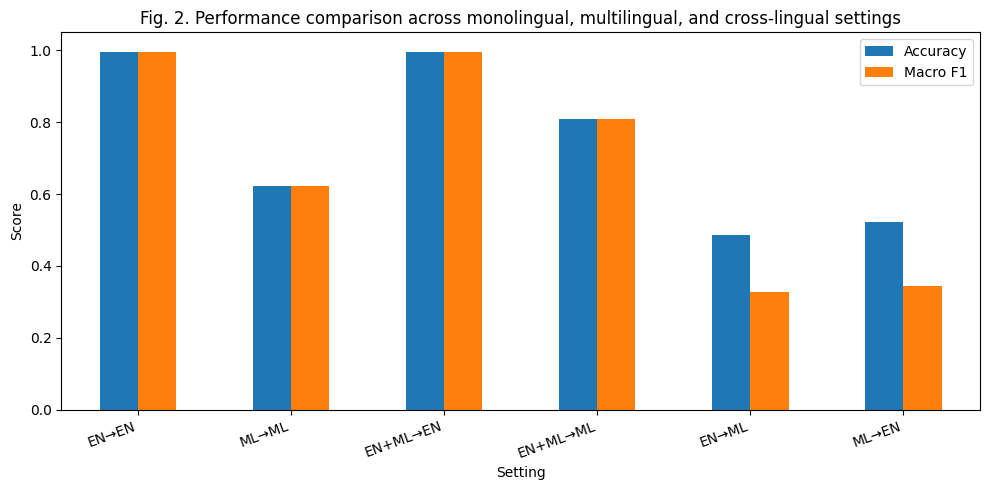

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Evaluate and store results (no retraining)
en_en      = trainer_en.evaluate(eval_dataset=en_test)  # EN→EN
ml_ml      = trainer_ml.evaluate(eval_dataset=ml_test)  # ML→ML

multi_on_en = trainer_multi.evaluate(
    eval_dataset=TextClsDataset(["<en> "+t for t in X_en_te], y_en_te, tokenizer, 128)
)  # EN+ML→EN

multi_on_ml = trainer_multi.evaluate(
    eval_dataset=TextClsDataset(["<ml> "+t for t in X_ml_te], y_ml_te, tokenizer, 128)
)  # EN+ML→ML

en_to_ml = trainer_en.evaluate(
    eval_dataset=TextClsDataset(["<ml> "+t for t in X_ml_te], y_ml_te, tokenizer, 128)
)  # EN→ML

ml_to_en = trainer_ml.evaluate(
    eval_dataset=TextClsDataset(["<en> "+t for t in X_en_te], y_en_te, tokenizer, 128)
)  # ML→EN


rows = [
    ("EN→EN", en_en["eval_accuracy"], en_en["eval_f1"]),
    ("ML→ML", ml_ml["eval_accuracy"], ml_ml["eval_f1"]),
    ("EN+ML→EN", multi_on_en["eval_accuracy"], multi_on_en["eval_f1"]),
    ("EN+ML→ML", multi_on_ml["eval_accuracy"], multi_on_ml["eval_f1"]),
    ("EN→ML", en_to_ml["eval_accuracy"], en_to_ml["eval_f1"]),
    ("ML→EN", ml_to_en["eval_accuracy"], ml_to_en["eval_f1"]),
]

df_plot = pd.DataFrame(rows, columns=["Setting", "Accuracy", "Macro F1"]).set_index("Setting")

ax = df_plot.plot(kind="bar", figsize=(10,5))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Fig. 2. Performance comparison across monolingual, multilingual, and cross-lingual settings")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("Performance_comparison.png", dpi=200)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def show_cm(trainer, dataset, y_true, title):
    preds = trainer.predict(dataset).predictions.argmax(axis=1)
    cm = confusion_matrix(y_true, preds)
    fig, ax = plt.subplots(figsize=(3, 3))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Fake", "Real"]
    )
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

    plt.tight_layout()
    plt.show()


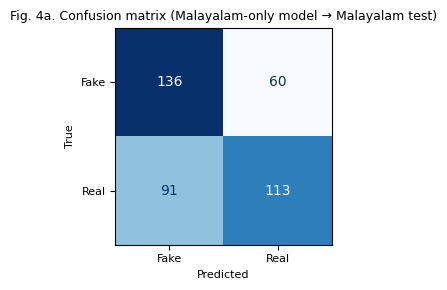

In [ ]:
show_cm(
    trainer_ml,
    ml_test,
    y_ml_te,
    "Fig. 4a. Confusion matrix (Malayalam-only model → Malayalam test)"
)
plt.show()


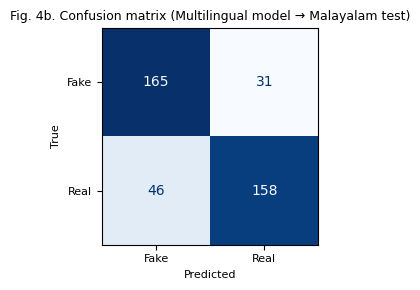

<Figure size 640x480 with 0 Axes>

In [ ]:
ml_test_tagged = TextClsDataset(["<ml> "+t for t in X_ml_te], y_ml_te, tokenizer, 128)

show_cm(
    trainer_multi,
    ml_test_tagged,
    y_ml_te,
    "Fig. 4b. Confusion matrix (Multilingual model → Malayalam test)"
)
plt.savefig("Confusion matrix multi.png", dpi=200)

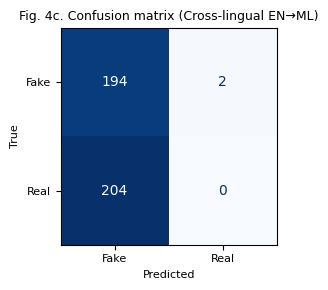

<Figure size 640x480 with 0 Axes>

In [ ]:
ml_test_for_en = TextClsDataset(["<ml> "+t for t in X_ml_te], y_ml_te, tokenizer, 128)

show_cm(
    trainer_en,
    ml_test_for_en,
    y_ml_te,
    "Fig. 4c. Confusion matrix (Cross-lingual EN→ML)"
)
plt.savefig("Confusion matrix cross.png", dpi=200)